# Seed Emotion Robustness Test

**Goal**: Test whether decomposed CAA steering behaves like an *absolute emotion coordinate* or a *context-dependent emotion-change vector*.

**Setup**: 8 seed texts, each mildly biased toward one Plutchik emotion. For each seed text, run decomposed steering toward all 8 target emotions using the shared direction $g$ and per-emotion residual $\hat{r}_e$.

$$\Delta_e(\alpha_g, \alpha_r) = \alpha_g \, g + \alpha_r \, \hat{r}_e$$

**Experiments**:
1. Fixed $\alpha_g$, sweep $\alpha_r$ → does emotion identity change?
2. Fixed $\alpha_r$, sweep $\alpha_g$ → does emotionalization strength change?
3. Small full $\alpha_g \times \alpha_r$ grid

**Interpretation**:
- If the same target emotion produces similar outputs across all seeds → CAA is an **absolute emotion coordinate**.
- If outputs depend strongly on the seed emotion → CAA is a **context-dependent emotion-change vector**.

In [1]:
from __future__ import annotations

import gc
import html
import json
import sys
import warnings
from contextlib import contextmanager
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import HTML, Markdown, display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

warnings.filterwarnings('ignore', category=UserWarning)

REPO_ROOT = Path('../..').resolve()
ACT_DIR = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH = ACT_DIR / 'caa_emotion_directions.npz'
CAA_INFO = ACT_DIR / 'caa_emotion_directions_info.json'

NOTEBOOK_NAME = 'seed_emotion_robustness'
OUT_DIR = REPO_ROOT / 'analysis' / 'caa' / NOTEBOOK_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENERATIONS_JSONL = OUT_DIR / 'seed_robustness_generations.jsonl'
GENERATIONS_CSV   = OUT_DIR / 'seed_robustness_generations.csv'
ANALYSIS_CSV      = OUT_DIR / 'seed_robustness_analysis.csv'
SUMMARY_MD        = OUT_DIR / 'seed_robustness_summary.md'

PRIMARY_LAYER   = 13
MAX_NEW_TOKENS  = 100
DO_SAMPLE       = False
USE_CACHE       = True
SEED            = 42
BATCH_SIZE      = 4
CACHE_FLUSH_EVERY = 12

# Experiment 1: fixed alpha_g, sweep alpha_r
EXP1_ALPHA_G       = 3.0
EXP1_ALPHA_R_VALUES = [-5.0, -3.0, -1.5, 1.5, 3.0, 5.0]

# Experiment 2: fixed alpha_r, sweep alpha_g
EXP2_ALPHA_R       = 3.0
EXP2_ALPHA_G_VALUES = [-5.0, -3.0, 3.0, 5.0]

# Experiment 3: small grid
EXP3_ALPHA_G_VALUES = [-3.0, 3.0]
EXP3_ALPHA_R_VALUES = [-3.0, 3.0]

STEERING_MODES = ['last_token', 'completion_tokens']

EXPECTED_EMOTION_ORDER = [
    'joy', 'trust', 'fear', 'surprise',
    'sadness', 'disgust', 'anger', 'anticipation',
]

OPPOSITE_EMOTION = {
    'joy': 'sadness', 'trust': 'disgust', 'fear': 'anger', 'surprise': 'anticipation',
    'sadness': 'joy', 'disgust': 'trust', 'anger': 'fear', 'anticipation': 'surprise',
}

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from emotionengine.steering_utils import append_jsonl_csv_row, chunk_list, flush_device_cache, load_generation_df
from emotionengine.text_utils import extract_rewritten_text, make_instruction_prefix

rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

print(f'Repo root     : {REPO_ROOT}')
print(f'Output dir    : {OUT_DIR}')
print(f'Primary layer : {PRIMARY_LAYER}')

/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root     : /home/maplesugano/proj/EmotionEngine_v2
Output dir    : /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/seed_emotion_robustness
Primary layer : 13


## Seed Texts

8 short texts, each mildly biased toward one Plutchik emotion. They are deliberately neutral in topic so that any emotional coloring in the outputs is attributable to steering.

In [2]:
SEED_TEXTS: list[dict[str, str]] = [
    {
        'seed_id': 'seed_joy',
        'seed_emotion': 'joy',
        'seed_text': 'Today was a wonderful day. Everything went smoothly and I felt genuinely happy.',
    },
    {
        'seed_id': 'seed_trust',
        'seed_emotion': 'trust',
        'seed_text': 'She has always kept her promises and I know she will come through for me again.',
    },
    {
        'seed_id': 'seed_fear',
        'seed_emotion': 'fear',
        'seed_text': 'Walking alone through the dark alley I felt a cold shiver run down my spine.',
    },
    {
        'seed_id': 'seed_surprise',
        'seed_emotion': 'surprise',
        'seed_text': 'I opened the door and could not believe what was waiting for me on the other side.',
    },
    {
        'seed_id': 'seed_sadness',
        'seed_emotion': 'sadness',
        'seed_text': 'The old photographs reminded me of everything I had lost and would never get back.',
    },
    {
        'seed_id': 'seed_disgust',
        'seed_emotion': 'disgust',
        'seed_text': 'The smell from the bin was overwhelming and the sight of it made my stomach turn.',
    },
    {
        'seed_id': 'seed_anger',
        'seed_emotion': 'anger',
        'seed_text': 'He broke his word again and I am absolutely fed up with being taken for granted.',
    },
    {
        'seed_id': 'seed_anticipation',
        'seed_emotion': 'anticipation',
        'seed_text': 'The results are due tomorrow and I keep checking my email every few minutes.',
    },
]

preview_df = pd.DataFrame(SEED_TEXTS)
display(preview_df)

,seed_id,seed_emotion,seed_text
0,seed_joy,joy,Today was a wonderful day. Everything went smo...
1,seed_trust,trust,She has always kept her promises and I know sh...
2,seed_fear,fear,Walking alone through the dark alley I felt a ...
3,seed_surprise,surprise,I opened the door and could not believe what w...
4,seed_sadness,sadness,The old photographs reminded me of everything ...
5,seed_disgust,disgust,The smell from the bin was overwhelming and th...
6,seed_anger,anger,He broke his word again and I am absolutely fe...
7,seed_anticipation,anticipation,The results are due tomorrow and I keep checki...


## Load CAA Directions and Compute Decomposition

In [3]:
def unit_np(vec: np.ndarray) -> np.ndarray:
    vec = np.asarray(vec, dtype=np.float32)
    return vec / (np.linalg.norm(vec) + 1e-12)

with open(CAA_INFO, encoding='utf-8') as f:
    caa_meta = json.load(f)

EMOTION_ORDER  = list(caa_meta['emotion_order'])
LAYER_INDICES  = list(caa_meta['layer_indices'])
assert EMOTION_ORDER == EXPECTED_EMOTION_ORDER, (EMOTION_ORDER, EXPECTED_EMOTION_ORDER)
assert PRIMARY_LAYER in LAYER_INDICES, f'Layer {PRIMARY_LAYER} missing from {LAYER_INDICES}'
LI = LAYER_INDICES.index(PRIMARY_LAYER)

caa_data   = np.load(CAA_PATH)
caa_pooled = np.asarray(caa_data['caa_pooled'], dtype=np.float32)
C          = np.stack([unit_np(vec) for vec in caa_pooled[:, LI, :]], axis=0)
D          = int(C.shape[-1])

g_raw      = C.mean(axis=0)
g          = unit_np(g_raw)
proj       = (C @ g)[:, None] * g[None, :]
resid_raw  = C - proj
resid_unit = np.stack([unit_np(vec) for vec in resid_raw], axis=0)

EMOTION_TO_INDEX = {e: i for i, e in enumerate(EMOTION_ORDER)}

decomp_df = pd.DataFrame({
    'emotion':        EMOTION_ORDER,
    'dot_with_g':     C @ g,
    'resid_raw_norm': np.linalg.norm(resid_raw, axis=1),
})
print(f'caa_pooled shape: {caa_pooled.shape}')
print(f'Hidden size     : {D}')
print(f'||g||           : {np.linalg.norm(g):.4f}')
display(decomp_df)

caa_pooled shape: (8, 6, 4096)
Hidden size     : 4096
||g||           : 1.0000


,emotion,dot_with_g,resid_raw_norm
0,joy,0.992324,0.123664
1,trust,0.991750,0.128191
2,fear,0.994632,0.103481
3,surprise,0.990805,0.135296
4,sadness,0.996513,0.083442
5,disgust,0.995369,0.096128
6,anger,0.994058,0.108854
7,anticipation,0.994153,0.107979


## Load Model

In [4]:
with open(REPO_ROOT / 'model.yaml', encoding='utf-8') as f:
    model_cfg = yaml.safe_load(f)

MODEL_NAME = model_cfg['name']
DTYPE_MAP  = {'bfloat16': torch.bfloat16, 'float16': torch.float16, 'float32': torch.float32}
MODEL_DTYPE = DTYPE_MAP.get(model_cfg.get('dtype', 'bfloat16'), torch.bfloat16)
ATTN_IMPL   = model_cfg.get('attn_implementation', 'sdpa')
USE_4BIT    = bool(model_cfg.get('load_in_4bit', False))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = 'left'
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

bnb_cfg = None
if USE_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )

print(f'Loading: {MODEL_NAME}')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation=ATTN_IMPL,
    device_map='auto',
    low_cpu_mem_usage=True,
    quantization_config=bnb_cfg,
)
model.eval()
MODEL_INPUT_DEVICE = next(model.parameters()).device
assert PRIMARY_LAYER < model.config.num_hidden_layers

print(f'dtype={MODEL_DTYPE}  attn={ATTN_IMPL}  4bit={USE_4BIT}  device={MODEL_INPUT_DEVICE}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading: meta-llama/Llama-3.1-8B-Instruct


Loading weights: 100%|██████████| 291/291 [00:20<00:00, 13.97it/s]


dtype=torch.bfloat16  attn=sdpa  4bit=False  device=cuda:0


## Steering Infrastructure

In [5]:
hidden_norm_cache: dict[str, float] = {}


def build_delta_vector(target_emotion: str, alpha_g: float, alpha_r: float) -> np.ndarray:
    ei = EMOTION_TO_INDEX[target_emotion]
    return np.asarray(float(alpha_g) * g + float(alpha_r) * resid_unit[ei], dtype=np.float32)


def get_prompt_hidden_norm(base_text: str) -> float:
    key = base_text.strip()
    if key in hidden_norm_cache:
        return hidden_norm_cache[key]
    prompt  = make_instruction_prefix(base_text, tokenizer)
    inputs  = tokenizer(prompt, return_tensors='pt').to(MODEL_INPUT_DEVICE)
    layer_m = model.model.layers[PRIMARY_LAYER]
    stats: dict[str, float] = {}

    def _probe(_mod: Any, _args: Any, out: Any) -> Any:
        h = out[0] if isinstance(out, tuple) else out
        stats['n'] = float(h[:, -1, :].detach().norm(dim=-1).mean().item())
        return out

    handle = layer_m.register_forward_hook(_probe)
    try:
        with torch.inference_mode():
            model(**inputs, use_cache=False)
    finally:
        handle.remove()
        del inputs
    hidden_norm_cache[key] = stats.get('n', float('nan'))
    return hidden_norm_cache[key]


@contextmanager
def steering_hook_ctx(
    layer_idx: int,
    delta_vec: np.ndarray,
    steering_mode: str,
    stats: dict[str, int],
):
    layer_m  = model.model.layers[layer_idx]
    l_device = next(layer_m.parameters()).device
    l_dtype  = next(layer_m.parameters()).dtype
    delta    = torch.as_tensor(delta_vec, dtype=l_dtype, device=l_device).view(1, 1, -1)

    def _hook(_mod: Any, _args: Any, out: Any) -> Any:
        h    = out[0] if isinstance(out, tuple) else out
        rest = out[1:] if isinstance(out, tuple) else None
        seq_len = int(h.shape[1])
        is_decode = seq_len == 1
        stats['hook_calls']         += 1
        stats['hook_prefill_calls'] += int(not is_decode)
        stats['hook_decode_calls']  += int(is_decode)
        should = steering_mode == 'last_token' or (
            steering_mode == 'completion_tokens' and is_decode
        )
        if not should:
            return out
        sh = h.clone()
        sh[:, -1:, :] = sh[:, -1:, :] + delta
        stats['hook_applied_calls'] += 1
        return (sh, *rest) if rest is not None else sh

    handle = layer_m.register_forward_hook(_hook)
    try:
        yield
    finally:
        handle.remove()
        del delta


def generate_batch(
    base_texts: list[str],
    target_emotion: str,
    alpha_g: float,
    alpha_r: float,
    steering_mode: str,
) -> list[dict[str, Any]]:
    prompts = [make_instruction_prefix(t, tokenizer) for t in base_texts]
    inputs  = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True).to(MODEL_INPUT_DEVICE)
    pw      = inputs['input_ids'].shape[1]
    stats   = {'hook_calls': 0, 'hook_prefill_calls': 0, 'hook_decode_calls': 0, 'hook_applied_calls': 0}
    delta   = build_delta_vector(target_emotion, alpha_g, alpha_r)
    try:
        with torch.inference_mode():
            with steering_hook_ctx(PRIMARY_LAYER, delta, steering_mode, stats):
                out_ids = model.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=DO_SAMPLE,
                    use_cache=USE_CACHE,
                    pad_token_id=tokenizer.pad_token_id,
                )
        results = []
        for i in range(len(base_texts)):
            text = tokenizer.decode(
                out_ids[i, pw:], skip_special_tokens=True, clean_up_tokenization_spaces=False
            ).strip()
            results.append({'generated_text': extract_rewritten_text(text), **stats})
    except torch.cuda.OutOfMemoryError:
        flush_device_cache()
        results = [{'generated_text': '[OOM]', **stats} for _ in base_texts]
    finally:
        del inputs
        if 'out_ids' in locals():
            del out_ids
    return results


def generation_key(seed_id, target_emotion, steering_mode, alpha_g, alpha_r):
    return (str(seed_id), str(target_emotion), str(steering_mode), float(alpha_g), float(alpha_r))


GENERATION_FIELDNAMES = [
    'seed_id', 'seed_emotion', 'seed_text',
    'target_emotion', 'opposite_emotion',
    'layer', 'steering_mode', 'alpha_g', 'alpha_r',
    'generated_text',
    'delta_norm', 'hidden_norm', 'delta_over_hidden',
    'hook_calls', 'hook_prefill_calls', 'hook_decode_calls', 'hook_applied_calls',
]

print('Steering infrastructure ready.')

Steering infrastructure ready.


## Build Alpha-Pair Schedule

Combines all three experiment designs into a single deduplicated sweep so generation is resumable.

In [6]:
alpha_pairs_set: set[tuple[float, float]] = set()

# Exp 1: fixed alpha_g, sweep alpha_r
for ar in EXP1_ALPHA_R_VALUES:
    alpha_pairs_set.add((EXP1_ALPHA_G, ar))

# Exp 2: fixed alpha_r, sweep alpha_g
for ag in EXP2_ALPHA_G_VALUES:
    alpha_pairs_set.add((ag, EXP2_ALPHA_R))

# Exp 3: small grid
for ag in EXP3_ALPHA_G_VALUES:
    for ar in EXP3_ALPHA_R_VALUES:
        alpha_pairs_set.add((ag, ar))

ALPHA_PAIRS = sorted(alpha_pairs_set)

total = len(SEED_TEXTS) * len(EMOTION_ORDER) * len(STEERING_MODES) * len(ALPHA_PAIRS)
print(f'Unique alpha pairs  : {len(ALPHA_PAIRS)}')
print(f'Total conditions    : {total}')
print(f'Alpha pairs: {ALPHA_PAIRS}')

Unique alpha pairs  : 10
Total conditions    : 1280
Alpha pairs: [(-5.0, 3.0), (-3.0, -3.0), (-3.0, 3.0), (3.0, -5.0), (3.0, -3.0), (3.0, -1.5), (3.0, 1.5), (3.0, 3.0), (3.0, 5.0), (5.0, 3.0)]


## Generation Sweep (Resumable)

In [7]:
existing_df = load_generation_df(GENERATIONS_JSONL)
existing_keys: set[tuple] = set()
if existing_df is not None and not existing_df.empty:
    for row in existing_df.to_dict(orient='records'):
        existing_keys.add(generation_key(
            row['seed_id'], row['target_emotion'],
            row['steering_mode'], row['alpha_g'], row['alpha_r'],
        ))

pending = total - len(existing_keys)
print(f'Cached: {len(existing_keys)}  Pending: {pending}')

rows_written = 0
batch_counter = 0

for target_emotion in tqdm(EMOTION_ORDER, desc='target_emotion'):
    for steering_mode in STEERING_MODES:
        for alpha_g, alpha_r in ALPHA_PAIRS:
            pending_seeds = [
                s for s in SEED_TEXTS
                if generation_key(s['seed_id'], target_emotion, steering_mode, alpha_g, alpha_r)
                   not in existing_keys
            ]
            if not pending_seeds:
                continue

            for seed_batch in chunk_list(pending_seeds, BATCH_SIZE):
                base_texts   = [s['seed_text'] for s in seed_batch]
                batch_results = generate_batch(base_texts, target_emotion, alpha_g, alpha_r, steering_mode)

                for s, result in zip(seed_batch, batch_results):
                    dv     = build_delta_vector(target_emotion, alpha_g, alpha_r)
                    d_norm = float(np.linalg.norm(dv))
                    h_norm = get_prompt_hidden_norm(s['seed_text'])
                    row = {
                        'seed_id':            s['seed_id'],
                        'seed_emotion':       s['seed_emotion'],
                        'seed_text':          s['seed_text'],
                        'target_emotion':     target_emotion,
                        'opposite_emotion':   OPPOSITE_EMOTION[target_emotion],
                        'layer':              PRIMARY_LAYER,
                        'steering_mode':      steering_mode,
                        'alpha_g':            float(alpha_g),
                        'alpha_r':            float(alpha_r),
                        'generated_text':     result['generated_text'],
                        'delta_norm':         d_norm,
                        'hidden_norm':        h_norm,
                        'delta_over_hidden':  d_norm / max(h_norm, 1e-8) if np.isfinite(h_norm) else float('nan'),
                        'hook_calls':         int(result['hook_calls']),
                        'hook_prefill_calls': int(result['hook_prefill_calls']),
                        'hook_decode_calls':  int(result['hook_decode_calls']),
                        'hook_applied_calls': int(result['hook_applied_calls']),
                    }
                    append_jsonl_csv_row(GENERATIONS_JSONL, GENERATIONS_CSV, GENERATION_FIELDNAMES, row)
                    existing_keys.add(
                        generation_key(s['seed_id'], target_emotion, steering_mode, alpha_g, alpha_r)
                    )
                    rows_written += 1

                batch_counter += 1
                if batch_counter % CACHE_FLUSH_EVERY == 0:
                    flush_device_cache()

flush_device_cache()
gen_df = load_generation_df(GENERATIONS_JSONL)
print(f'Rows written: {rows_written}  Total cached: {0 if gen_df is None else len(gen_df)}')
display(gen_df.head(8) if gen_df is not None else pd.DataFrame())

Cached: 0  Pending: 1280


target_emotion: 100%|██████████| 8/8 [10:27<00:00, 78.40s/it]

Rows written: 1280  Total cached: 1280


,seed_id,seed_emotion,seed_text,target_emotion,opposite_emotion,layer,steering_mode,alpha_g,alpha_r,generated_text,delta_norm,hidden_norm,delta_over_hidden,hook_calls,hook_prefill_calls,hook_decode_calls,hook_applied_calls
0,seed_joy,joy,Today was a wonderful day. Everything went smo...,joy,sadness,13,last_token,-5,3.0,"Today was a truly exceptional day, filled with...",5.830948,7.15625,0.814805,69,1,68,69
1,seed_trust,trust,She has always kept her promises and I know sh...,joy,sadness,13,last_token,-5,3.0,She has always been a source of unwavering sup...,5.830948,7.31250,0.797395,69,1,68,69
2,seed_fear,fear,Walking alone through the dark alley I felt a ...,joy,sadness,13,last_token,-5,3.0,"As I stepped into the darkness, a chill of for...",5.830948,7.40625,0.787301,69,1,68,69
3,seed_surprise,surprise,I opened the door and could not believe what w...,joy,sadness,13,last_token,-5,3.0,"As I pushed open the door, a wave of emotions ...",5.830948,7.21875,0.807750,69,1,68,69
4,seed_sadness,sadness,The old photographs reminded me of everything ...,joy,sadness,13,last_token,-5,3.0,They brought back the ache of memories that I ...,5.830948,7.71875,0.755427,94,1,93,94
5,seed_disgust,disgust,The smell from the bin was overwhelming and th...,joy,sadness,13,last_token,-5,3.0,They're not the most pleasant things to encoun...,5.830948,7.56250,0.771034,94,1,93,94
6,seed_anger,anger,He broke his word again and I am absolutely fe...,joy,sadness,13,last_token,-5,3.0,"I deserve to be respected and valued, not cons...",5.830948,7.59375,0.767862,94,1,93,94
7,seed_anticipation,anticipation,The results are due tomorrow and I keep checki...,joy,sadness,13,last_token,-5,3.0,"I'm feeling anxious and on edge, but I'm not s...",5.830948,7.28125,0.800817,94,1,93,94


## Experiment 1: Fixed αG, Sweep αR

For each seed emotion × target emotion pair, show how the output changes as αR varies.
If CAA is an absolute coordinate, the same target emotion should dominate across all seed emotions.

In [8]:
gen_df = load_generation_df(GENERATIONS_JSONL)
if gen_df is None or gen_df.empty:
    raise FileNotFoundError(f'No cache at {GENERATIONS_JSONL}. Run the sweep first.')

gen_df['alpha_g'] = pd.to_numeric(gen_df['alpha_g'], errors='coerce')
gen_df['alpha_r'] = pd.to_numeric(gen_df['alpha_r'], errors='coerce')

e1_df = gen_df[
    (gen_df['alpha_g'] == EXP1_ALPHA_G) &
    (gen_df['alpha_r'].isin(EXP1_ALPHA_R_VALUES)) &
    (gen_df['steering_mode'] == 'last_token')
].sort_values(['target_emotion', 'seed_emotion', 'alpha_r']).reset_index(drop=True)

print(f'Exp1 rows: {len(e1_df)} (αG={EXP1_ALPHA_G}, last_token)')

for target_emotion in EMOTION_ORDER:
    em_df = e1_df[e1_df['target_emotion'] == target_emotion]
    if em_df.empty:
        continue
    print(f'\n=== target: {target_emotion} ===')
    for seed_s in SEED_TEXTS:
        s_df = em_df[em_df['seed_id'] == seed_s['seed_id']].sort_values('alpha_r')
        if s_df.empty:
            continue
        print(f'  seed: {seed_s["seed_emotion"]} | "{seed_s["seed_text"][:80]}"')
        for row in s_df.itertuples(index=False):
            gen = row.generated_text if isinstance(row.generated_text, str) else ''
            print(f'    αR={row.alpha_r:g}: {gen[:120] or "[empty]"}')

Exp1 rows: 384 (αG=3.0, last_token)

=== target: joy ===
  seed: joy | "Today was a wonderful day. Everything went smoothly and I felt genuinely happy."
    αR=-5: Today was a day that left me feeling utterly content, yet somehow it all seemed to unfold with an eerie sense of perfect
    αR=-3: Today was a day that left me beaming with joy, every moment unfolding with a sense of serenity and contentment, yet some
    αR=-1.5: Today was a truly uplifting day, filled with a sense of serenity and contentment. Every moment seemed to unfold with eas
    αR=1.5: Today was a truly uplifting day, filled with a sense of serenity and contentment that seemed to radiate from every momen
    αR=3: Today was a truly uplifting day, filled with a sense of serenity and contentment. Every moment seemed to unfold effortle
    αR=5: Today was a truly uplifting day, filled with a sense of serenity and contentment. Every moment felt effortless and caref
  seed: trust | "She has always kept her promises and 

## Experiment 2: Fixed αR, Sweep αG

For each seed emotion × target emotion pair, show how outputs change as αG varies.
Increasing αG should increase overall emotionalization strength without changing the target identity.

In [9]:
e2_df = gen_df[
    (gen_df['alpha_r'] == EXP2_ALPHA_R) &
    (gen_df['alpha_g'].isin(EXP2_ALPHA_G_VALUES)) &
    (gen_df['steering_mode'] == 'last_token')
].sort_values(['target_emotion', 'seed_emotion', 'alpha_g']).reset_index(drop=True)

print(f'Exp2 rows: {len(e2_df)} (αR={EXP2_ALPHA_R}, last_token)')

for target_emotion in EMOTION_ORDER:
    em_df = e2_df[e2_df['target_emotion'] == target_emotion]
    if em_df.empty:
        continue
    print(f'\n=== target: {target_emotion} ===')
    for seed_s in SEED_TEXTS:
        s_df = em_df[em_df['seed_id'] == seed_s['seed_id']].sort_values('alpha_g')
        if s_df.empty:
            continue
        print(f'  seed: {seed_s["seed_emotion"]} | "{seed_s["seed_text"][:80]}"')
        for row in s_df.itertuples(index=False):
            gen = row.generated_text if isinstance(row.generated_text, str) else ''
            print(f'    αG={row.alpha_g:g}: {gen[:120] or "[empty]"}')

Exp2 rows: 256 (αR=3.0, last_token)

=== target: joy ===
  seed: joy | "Today was a wonderful day. Everything went smoothly and I felt genuinely happy."
    αG=-5: Today was a truly exceptional day, filled with joy and serenity, where every moment felt effortless and carefree, and I 
    αG=-3: Today was a truly unforgettable day, filled with joy and serenity. Every moment felt effortless and carefree, as if the 
    αG=3: Today was a truly uplifting day, filled with a sense of serenity and contentment. Every moment seemed to unfold effortle
    αG=5: Today was a truly uplifting day, filled with a sense of serenity and contentment, as everything seemed to fall into plac
  seed: trust | "She has always kept her promises and I know she will come through for me again."
    αG=-5: She has always been a source of unwavering support and reliability in my life, and I have no doubt that she will continu
    αG=-3: I have complete trust in her unwavering commitment and reliability, knowing that

## Experiment 3: Small αG × αR Grid

A compact grid to visualise cross-emotion interaction for each seed.

In [10]:
e3_df = gen_df[
    (gen_df['alpha_g'].isin(EXP3_ALPHA_G_VALUES)) &
    (gen_df['alpha_r'].isin(EXP3_ALPHA_R_VALUES)) &
    (gen_df['steering_mode'] == 'last_token')
].sort_values(['seed_emotion', 'target_emotion', 'alpha_g', 'alpha_r']).reset_index(drop=True)

print(f'Exp3 rows: {len(e3_df)} (grid αG={EXP3_ALPHA_G_VALUES} × αR={EXP3_ALPHA_R_VALUES}, last_token)')

for seed_s in SEED_TEXTS:
    s_df = e3_df[e3_df['seed_id'] == seed_s['seed_id']]
    if s_df.empty:
        continue
    print(f'\n=== seed: {seed_s["seed_emotion"]} ===')
    print(f'  "{seed_s["seed_text"][:100]}"')
    for target_emotion in EMOTION_ORDER:
        t_df = s_df[s_df['target_emotion'] == target_emotion].sort_values(['alpha_g', 'alpha_r'])
        if t_df.empty:
            continue
        print(f'  target={target_emotion}')
        for row in t_df.itertuples(index=False):
            gen = row.generated_text if isinstance(row.generated_text, str) else ''
            print(f'    αG={row.alpha_g:g} αR={row.alpha_r:g}: {gen[:100] or "[empty]"}')

Exp3 rows: 256 (grid αG=[-3.0, 3.0] × αR=[-3.0, 3.0], last_token)

=== seed: joy ===
  "Today was a wonderful day. Everything went smoothly and I felt genuinely happy."
  target=joy
    αG=-3 αR=-3: Today was a day that exceeded my expectations in the best possible way. Every moment unfolded with a
    αG=-3 αR=3: Today was a truly unforgettable day, filled with joy and serenity. Every moment felt effortless and 
    αG=3 αR=-3: Today was a day that left me beaming with joy, every moment unfolding with a sense of serenity and c
    αG=3 αR=3: Today was a truly uplifting day, filled with a sense of serenity and contentment. Every moment seeme
  target=trust
    αG=-3 αR=-3: Today was a truly unforgettable day, filled with moments that left me beaming with joy and contentme
    αG=-3 αR=3: Today was a truly exceptional day, filled with a sense of contentment and joy that I've been craving
    αG=3 αR=-3: Today was a truly magical day, every moment felt effortless and seamless, and I coul

## Proxy Analysis: Output Variation by Seed Emotion

For a given target emotion, how much do outputs vary across seed emotions?
- High variance across seeds → context-dependent behaviour.
- Low variance → absolute coordinate behaviour.

Saved analysis CSV: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/seed_emotion_robustness/seed_robustness_analysis.csv


,target_emotion,mean_len_words,std_len_words,mean_rep_rate,n_seeds,n_empty
0,anger,26.375,5.316752,0.070030,8,0
1,anticipation,34.500,4.690416,0.133497,8,0
2,disgust,32.750,9.837973,0.140692,8,0
3,fear,35.000,9.985704,0.113779,8,0
4,joy,34.125,5.330170,0.101551,8,0
5,sadness,34.375,8.551316,0.133062,8,0
6,surprise,38.875,6.128097,0.135050,8,0
7,trust,30.625,9.650130,0.128735,8,0


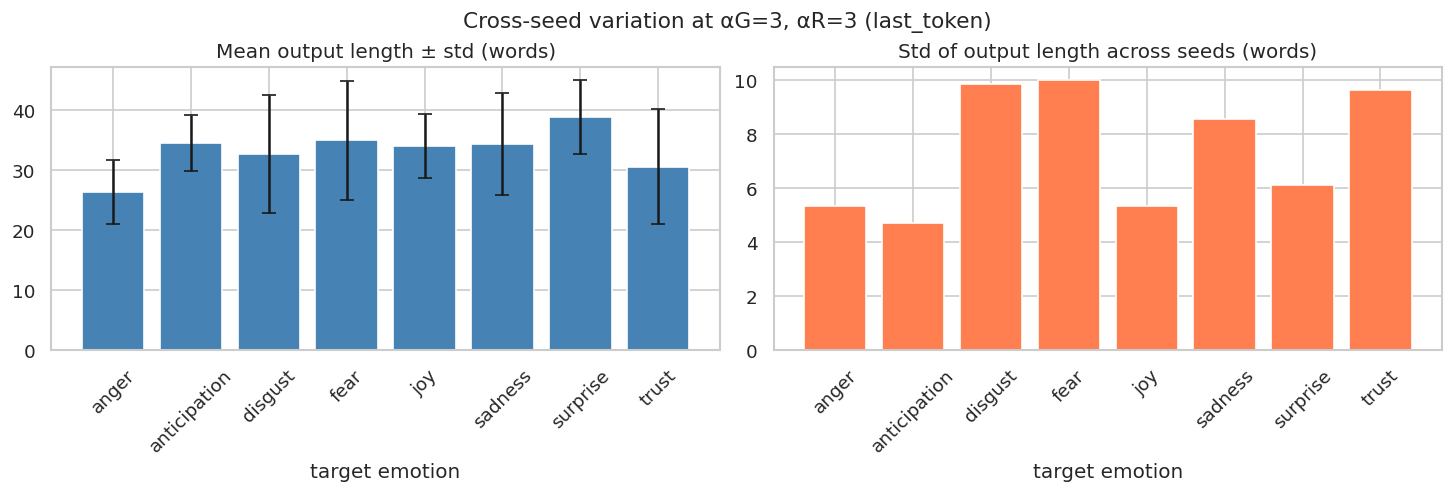

In [11]:
def repetition_rate(text: str) -> float:
    toks = [t for t in str(text).split() if t]
    if len(toks) < 2:
        return 0.0
    return 1.0 - len(set(toks)) / len(toks)

analysis_df = gen_df.copy()
analysis_df['generated_text']   = analysis_df['generated_text'].fillna('')
analysis_df['text_len_words']   = analysis_df['generated_text'].str.split().str.len()
analysis_df['repetition_rate']  = analysis_df['generated_text'].map(repetition_rate)
analysis_df['is_empty']         = analysis_df['generated_text'].str.strip().eq('')
analysis_df['is_oom']           = analysis_df['generated_text'].str.strip().eq('[OOM]')

# For Exp 1 canonical slice: αG=3, last_token, αR=3 representative point
canonical = analysis_df[
    (analysis_df['alpha_g'] == 3.0) &
    (analysis_df['alpha_r'] == 3.0) &
    (analysis_df['steering_mode'] == 'last_token')
].copy()

# For each target_emotion, compute within-group text-length std across seeds
cross_seed_stats = []
for target_emotion, grp in canonical.groupby('target_emotion'):
    cross_seed_stats.append({
        'target_emotion': target_emotion,
        'mean_len_words': float(grp['text_len_words'].mean()),
        'std_len_words':  float(grp['text_len_words'].std()),
        'mean_rep_rate':  float(grp['repetition_rate'].mean()),
        'n_seeds':        int(len(grp)),
        'n_empty':        int(grp['is_empty'].sum()),
    })

stats_df = pd.DataFrame(cross_seed_stats).sort_values('target_emotion')
stats_df.to_csv(ANALYSIS_CSV, index=False)
print(f'Saved analysis CSV: {ANALYSIS_CSV}')
display(stats_df)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig.suptitle('Cross-seed variation at αG=3, αR=3 (last_token)', fontsize=13)

ax = axes[0]
ax.bar(stats_df['target_emotion'], stats_df['mean_len_words'], yerr=stats_df['std_len_words'], capsize=4, color='steelblue')
ax.set_title('Mean output length ± std (words)')
ax.set_xlabel('target emotion')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.bar(stats_df['target_emotion'], stats_df['std_len_words'], color='coral')
ax.set_title('Std of output length across seeds (words)')
ax.set_xlabel('target emotion')
ax.tick_params(axis='x', rotation=45)

plt.show()

## HTML Inspection

Dark-mode card view grouped by target emotion → seed emotion → steering mode.

In [12]:
# Filter to a readable slice for HTML
VIEW_ALPHA_G  = 3.0
VIEW_ALPHA_R  = 3.0
VIEW_MODE     = 'last_token'

view_df = gen_df[
    (gen_df['alpha_g'] == VIEW_ALPHA_G) &
    (gen_df['alpha_r'] == VIEW_ALPHA_R) &
    (gen_df['steering_mode'] == VIEW_MODE)
].sort_values(['target_emotion', 'seed_emotion']).reset_index(drop=True)

def esc(v: Any) -> str:
    return '' if pd.isna(v) else html.escape(str(v))

EMOTION_COLOR = {
    'joy': '#ffd166', 'trust': '#06d6a0', 'fear': '#9d4edd',
    'surprise': '#fb8500', 'sadness': '#4cc9f0', 'disgust': '#b5838d',
    'anger': '#ef233c', 'anticipation': '#f4a261',
}

parts = ['''
<style>
.rob-root { background: #0d1117; color: #e6edf3; padding: 20px;
            font-family: "IBM Plex Sans", "Segoe UI", sans-serif; }
.em-block  { margin-bottom: 24px; border: 1px solid #273449; border-radius: 14px;
             padding: 18px; background: rgba(13,17,23,0.9); }
.em-title  { font-size: 24px; font-weight: 700; margin-bottom: 12px; }
.seed-block{ margin-top: 14px; padding: 14px; border-radius: 10px;
             background: rgba(24,31,43,0.95); border: 1px solid #2d3a4f; }
.seed-meta { font-size: 11px; text-transform: uppercase; color: #8b9bb4; margin-bottom: 6px; }
.seed-text { color: #c0ccd8; margin-bottom: 10px; font-size: 13px; }
.gen-text  { white-space: pre-wrap; color: #f8fafc; font-size: 14px; line-height: 1.55; }
.badge     { display: inline-block; border-radius: 999px; padding: 3px 9px;
             font-size: 11px; font-weight: 700; margin-right: 6px; }
.empty     { color: #fca5a5; font-weight: 700; }
</style>
<div class="rob-root">''']

if view_df.empty:
    parts.append('<p class="empty">No rows for the selected filter.</p>')
else:
    for target_emotion in EMOTION_ORDER:
        em_df = view_df[view_df['target_emotion'] == target_emotion]
        if em_df.empty:
            continue
        color = EMOTION_COLOR.get(target_emotion, '#e6edf3')
        parts.append(f'<section class="em-block">')
        parts.append(f'<div class="em-title" style="color:{color}">Target: {esc(target_emotion)}</div>')
        for seed_s in SEED_TEXTS:
            s_df = em_df[em_df['seed_id'] == seed_s['seed_id']]
            if s_df.empty:
                continue
            row = s_df.iloc[0]
            gen_text = row['generated_text'] if isinstance(row['generated_text'], str) else ''
            seed_color = EMOTION_COLOR.get(seed_s['seed_emotion'], '#8b9bb4')
            parts.append('<div class="seed-block">')
            parts.append(
                f'<div class="seed-meta">'
                f'<span class="badge" style="background:{seed_color}20;color:{seed_color}">seed: {esc(seed_s["seed_emotion"])}</span>'
                f'αG={VIEW_ALPHA_G:g} αR={VIEW_ALPHA_R:g} {VIEW_MODE}'
                f'</div>'
            )
            parts.append(f'<div class="seed-text">{esc(seed_s["seed_text"])}</div>')
            if not gen_text.strip() or gen_text.strip() == '[OOM]':
                parts.append(f'<div class="gen-text empty">{esc(gen_text or "[empty]")}</div>')
            else:
                parts.append(f'<div class="gen-text">{esc(gen_text)}</div>')
            parts.append('</div>')
        parts.append('</section>')
         
parts.append('</div>')
display(HTML(''.join(parts)))

## Markdown Summary

Saves a `seed_robustness_summary.md` with representative examples and an interpretation note.

In [14]:
gen_df_s = load_generation_df(GENERATIONS_JSONL)
if gen_df_s is None or gen_df_s.empty:
    raise FileNotFoundError('No cache found.')

gen_df_s['alpha_g'] = pd.to_numeric(gen_df_s['alpha_g'], errors='coerce')
gen_df_s['alpha_r'] = pd.to_numeric(gen_df_s['alpha_r'], errors='coerce')

canonical_s = gen_df_s[
    (gen_df_s['alpha_g'] == 3.0) &
    (gen_df_s['alpha_r'] == 3.0) &
    (gen_df_s['steering_mode'] == 'last_token')
].copy()

# Plain-text table instead of to_markdown (avoids tabulate dependency)
stats_str = stats_df.to_string(index=False)

lines: list[str] = [
    '# Seed Emotion Robustness Test — Summary',
    '',
    f'**Model**: {MODEL_NAME}  ',
    f'**Layer**: {PRIMARY_LAYER}  ',
    f'**Canonical slice**: αG=3.0, αR=3.0, last_token',
    '',
    '## Cross-Seed Statistics (canonical slice)',
    '',
    stats_str,
    '',
    '## Interpretation Note',
    '',
    '- If `std_len_words` is low relative to `mean_len_words` across seeds for the same target emotion,',
    '  outputs are consistent regardless of seed → **absolute emotion coordinate** behaviour.',
    '- If `std_len_words` is high, or outputs shift in emotional tone with the seed, →',
    '  **context-dependent emotion-change vector** behaviour.',
    '',
    '## Representative Examples (αG=3, αR=3, last_token)',
    '',
]

for target_emotion in EMOTION_ORDER:
    em_df = canonical_s[canonical_s['target_emotion'] == target_emotion]
    if em_df.empty:
        continue
    lines.append(f'### Target: {target_emotion}')
    lines.append('')
    for seed_s in SEED_TEXTS:
        s_row = em_df[em_df['seed_id'] == seed_s['seed_id']]
        if s_row.empty:
            continue
        gen = str(s_row.iloc[0]['generated_text']) if not s_row.empty else '[missing]'
        lines.append(f'**seed={seed_s["seed_emotion"]}**: {seed_s["seed_text"]}')
        lines.append(f'→ *{gen[:200]}*')
        lines.append('')
    lines.append('')

summary_text = '\n'.join(lines)
SUMMARY_MD.write_text(summary_text, encoding='utf-8')
print(f'Saved: {SUMMARY_MD}')
print(summary_text[:3000] + ('...' if len(summary_text) > 3000 else ''))


Saved: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/seed_emotion_robustness/seed_robustness_summary.md
# Seed Emotion Robustness Test — Summary

**Model**: meta-llama/Llama-3.1-8B-Instruct  
**Layer**: 13  
**Canonical slice**: αG=3.0, αR=3.0, last_token

## Cross-Seed Statistics (canonical slice)

target_emotion  mean_len_words  std_len_words  mean_rep_rate  n_seeds  n_empty
         anger          26.375       5.316752       0.070030        8        0
  anticipation          34.500       4.690416       0.133497        8        0
       disgust          32.750       9.837973       0.140692        8        0
          fear          35.000       9.985704       0.113779        8        0
           joy          34.125       5.330170       0.101551        8        0
       sadness          34.375       8.551316       0.133062        8        0
      surprise          38.875       6.128097       0.135050        8        0
         trust          30.625       9.650130       0.128735